In [1]:
!pip install seaborn scikit-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("Mall_Customers.csv")

print(df.head(10))
print(df.shape)
print(df.columns.tolist())
print(df.isnull().sum())
print(df.describe())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
5           6  Female   22                  17                      76
6           7  Female   35                  18                       6
7           8  Female   23                  18                      94
8           9    Male   64                  19                       3
9          10  Female   30                  19                      72
(200, 5)
['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-

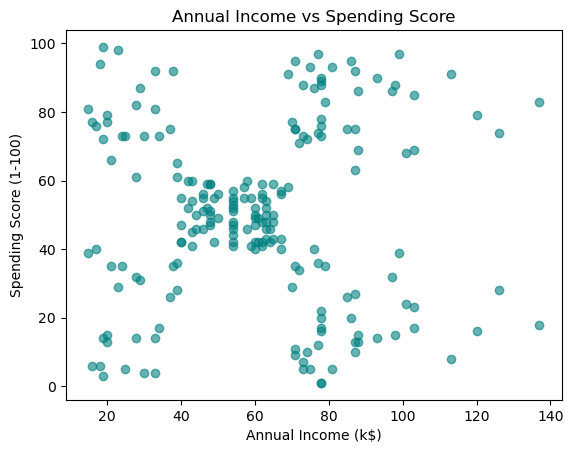

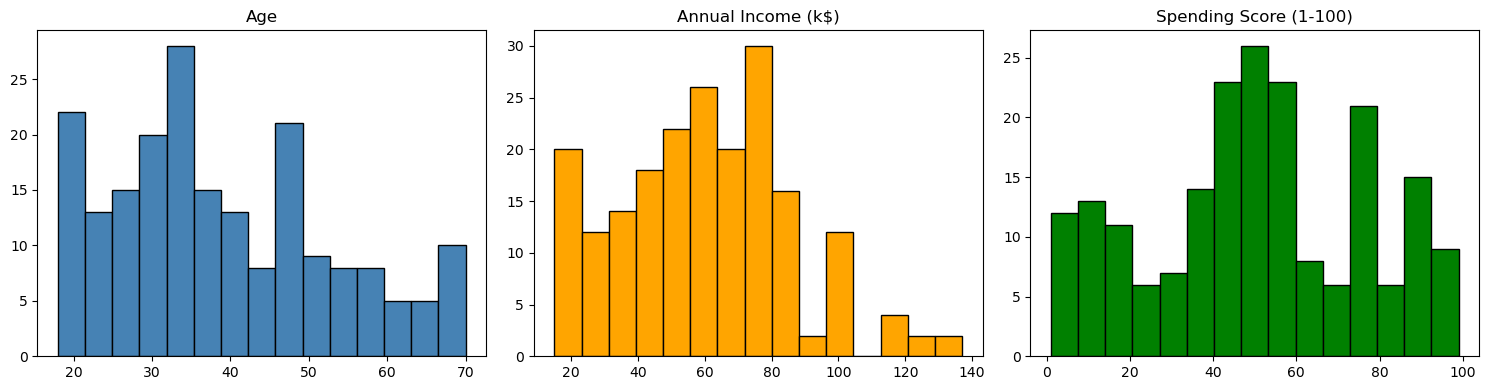

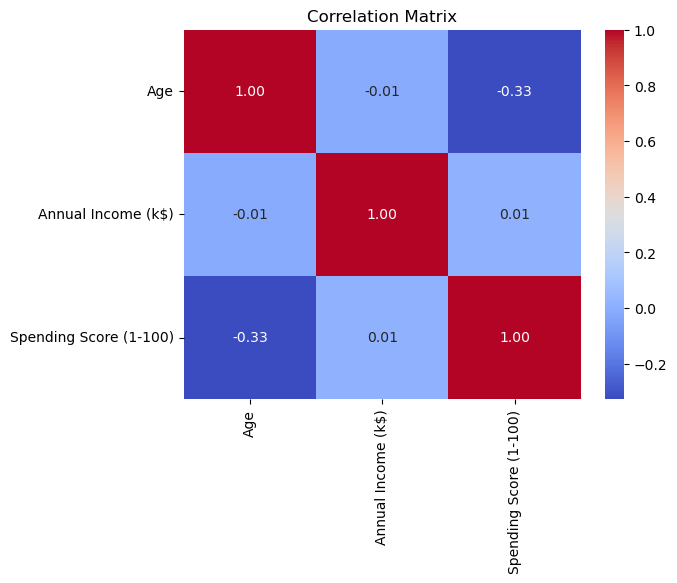

In [3]:
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], color='teal', alpha=0.6)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Annual Income vs Spending Score')
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, color in zip(axes, ['Age', 'Annual Income (k$)', 'Spending Score (1-100)'], ['steelblue', 'orange', 'green']):
    ax.hist(df[col], bins=15, color=color, edgecolor='black')
    ax.set_title(col)
plt.tight_layout()
plt.show()

sns.heatmap(df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [4]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

  File "c:\Users\HP\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\HP\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\HP\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\HP\anaconda3\Lib\subprocess.py", line 15

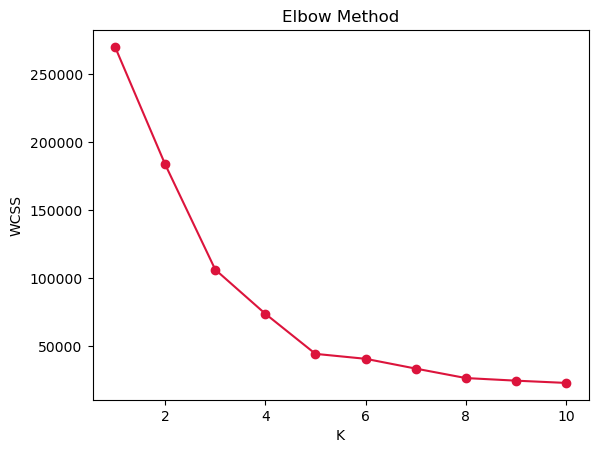

In [5]:
wcss = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, init='k-means++', random_state=42)
    km.fit(X)
    wcss.append(km.inertia_)

plt.plot(range(1, 11), wcss, marker='o', color='crimson')
plt.xlabel('K')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

In [6]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
kmeans.fit(X)
df['Cluster'] = kmeans.labels_
print(df.head(10))

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   
5           6  Female   22                  17                      76   
6           7  Female   35                  18                       6   
7           8  Female   23                  18                      94   
8           9    Male   64                  19                       3   
9          10  Female   30                  19                      72   

   Cluster  
0        4  
1        2  
2        4  
3        2  
4        4  
5        2  
6        4  
7        2  
8        4  
9        2  


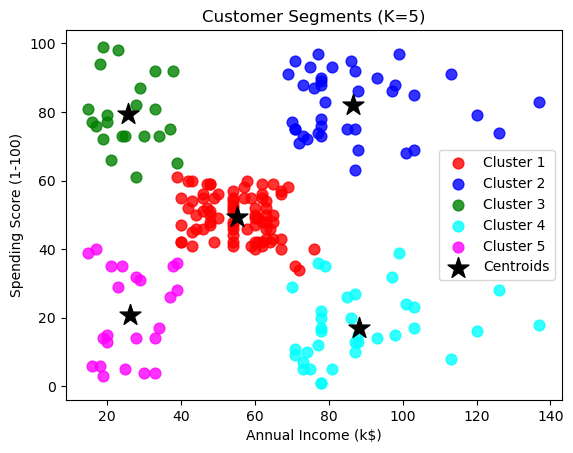

         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 55.296296               49.518519
1                 86.538462               82.128205
2                 25.727273               79.363636
3                 88.200000               17.114286
4                 26.304348               20.913043


In [7]:
colors_list = ['red', 'blue', 'green', 'cyan', 'magenta']

for i in range(5):
    plt.scatter(X[kmeans.labels_ == i, 0], X[kmeans.labels_ == i, 1],
                s=60, c=colors_list[i], label=f'Cluster {i+1}', alpha=0.8)

plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=250, c='black', marker='*', label='Centroids')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segments (K=5)')
plt.legend()
plt.show()

print(df.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean())

In [8]:
cluster_summary = df.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()
print(cluster_summary)

print("\nQ19 - Cluster Identification:")
print("High Income - High Spending  ->", cluster_summary[cluster_summary['Annual Income (k$)'] > 70][cluster_summary['Spending Score (1-100)'] > 60].index.tolist())
print("High Income - Low Spending   ->", cluster_summary[cluster_summary['Annual Income (k$)'] > 70][cluster_summary['Spending Score (1-100)'] < 40].index.tolist())
print("Low Income  - High Spending  ->", cluster_summary[cluster_summary['Annual Income (k$)'] < 40][cluster_summary['Spending Score (1-100)'] > 60].index.tolist())
print("Low Income  - Low Spending   ->", cluster_summary[cluster_summary['Annual Income (k$)'] < 40][cluster_summary['Spending Score (1-100)'] < 40].index.tolist())

print("\nQ20 - Most Valuable Segment:")
print("High Income - High Spending customers are most valuable.")
print("They have strong purchasing power and already spend heavily, maximizing business revenue.")

print("\nQ21 - Growth Opportunity Segment:")
print("Low Income - High Spending customers have the most growth potential.")
print("They are enthusiastic spenders, targeted discounts and EMI options can retain and grow them.")

print("\nQ22 - Marketing Strategies:")
print("High Income - High Spending : Premium memberships, exclusive products, VIP offers")
print("High Income - Low Spending  : Trust-building campaigns, highlight quality and value")
print("Low Income  - High Spending : Discount coupons, budget deals, installment schemes")
print("Low Income  - Low Spending  : Awareness ads, entry-level products, free trials")
print("Middle Cluster              : Seasonal offers, personalized product recommendations")

         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 55.296296               49.518519
1                 86.538462               82.128205
2                 25.727273               79.363636
3                 88.200000               17.114286
4                 26.304348               20.913043

Q19 - Cluster Identification:
High Income - High Spending  -> [1]
High Income - Low Spending   -> [3]
Low Income  - High Spending  -> [2]
Low Income  - Low Spending   -> [4]

Q20 - Most Valuable Segment:
High Income - High Spending customers are most valuable.
They have strong purchasing power and already spend heavily, maximizing business revenue.

Q21 - Growth Opportunity Segment:
Low Income - High Spending customers have the most growth potential.
They are enthusiastic spenders, targeted discounts and EMI options can retain and grow them.

Q22 - Marketing Strategies:
High Income - High Spending : Premium memberships, exclusi

In [9]:
print("\nQ23 - Summary:")
print("K-Means divided 200 customers into 5 segments based on income and spending.")
print("Two extreme groups clearly visible: high spenders and low spenders at both income levels.")
print("Middle cluster is the largest group with average behavior on both features.")

print("\nQ24 - Business Use:")
print("Marketing campaigns can be designed separately for each cluster.")
print("Budget can be focused on high value and high potential clusters.")
print("Product recommendations and offers can be personalized per group.")

print("\nQ25 - Advantages:")
print("Simple and fast algorithm, easy to interpret via centroids.")
print("Scales well to large datasets.")
print("\nLimitations:")
print("K must be defined manually before running.")
print("Outliers can pull centroids away from actual cluster centers.")
print("Assumes clusters are spherical which is not always the case in real data.")


Q23 - Summary:
K-Means divided 200 customers into 5 segments based on income and spending.
Two extreme groups clearly visible: high spenders and low spenders at both income levels.
Middle cluster is the largest group with average behavior on both features.

Q24 - Business Use:
Marketing campaigns can be designed separately for each cluster.
Budget can be focused on high value and high potential clusters.
Product recommendations and offers can be personalized per group.

Q25 - Advantages:
Simple and fast algorithm, easy to interpret via centroids.
Scales well to large datasets.

Limitations:
K must be defined manually before running.
Outliers can pull centroids away from actual cluster centers.
Assumes clusters are spherical which is not always the case in real data.
